In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# Tesla Deliveries and Production Analysis (2015–2025)

## Data Loading

## Data Cleaning

## Exploratory Data Analysis

## Visualizations

## Key Findings

## Business Recommendations

## Conclusion

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print(df.shape)
print(df.columns)
df.head()

(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values:
Year                    0
Month                   0
Region                  0
Model          

In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


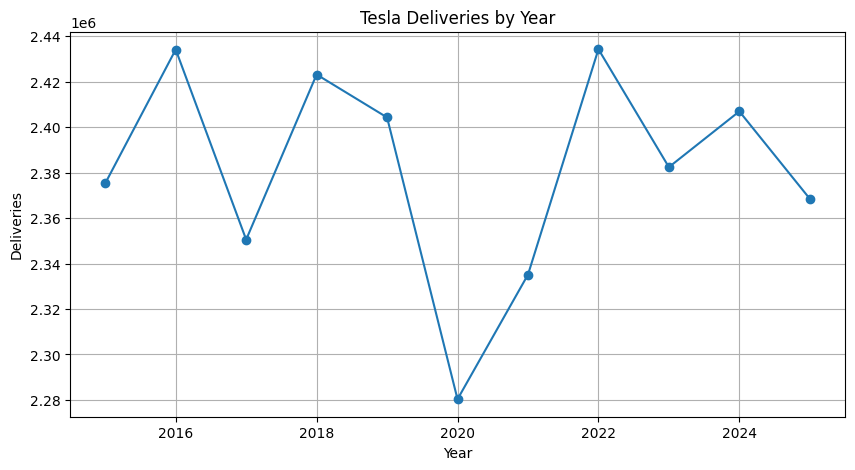

In [6]:
import matplotlib.pyplot as plt

yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
yearly_deliveries.plot(marker='o')
plt.title("Tesla Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Deliveries")
plt.grid(True)
plt.show()

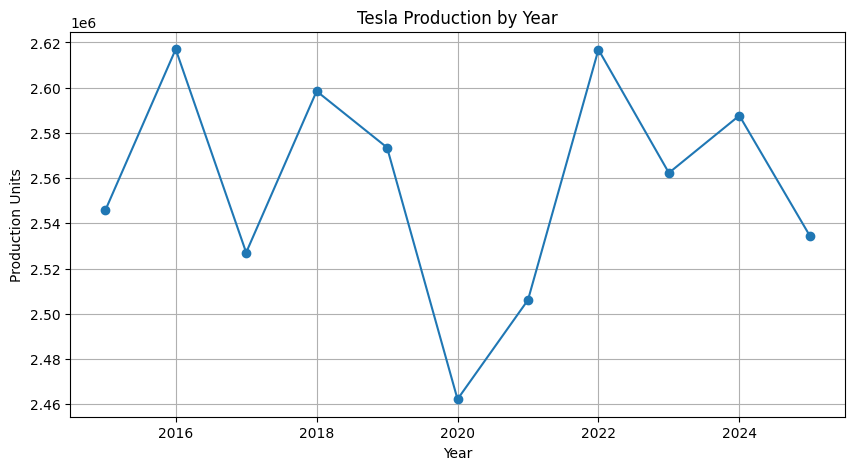

In [7]:
yearly_prod = df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(10,5))
yearly_prod.plot(marker='o')
plt.title("Tesla Production by Year")
plt.xlabel("Year")
plt.ylabel("Production Units")
plt.grid(True)
plt.show()

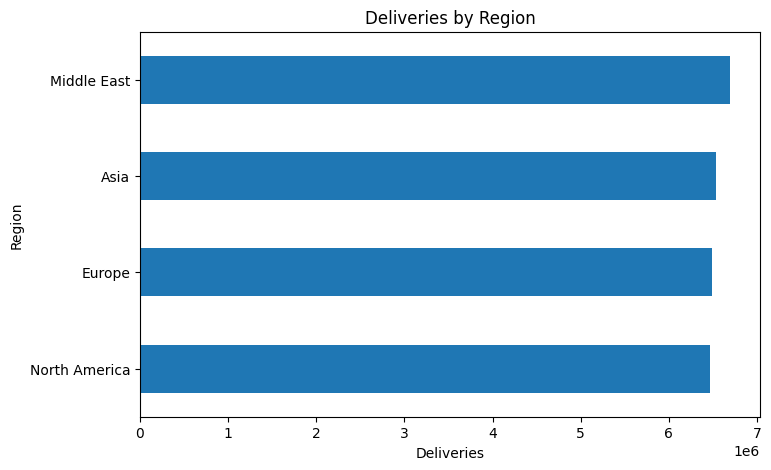

In [8]:
region_del = df.groupby('Region')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8,5))
region_del.sort_values().plot(kind='barh')
plt.title("Deliveries by Region")
plt.xlabel("Deliveries")
plt.show()

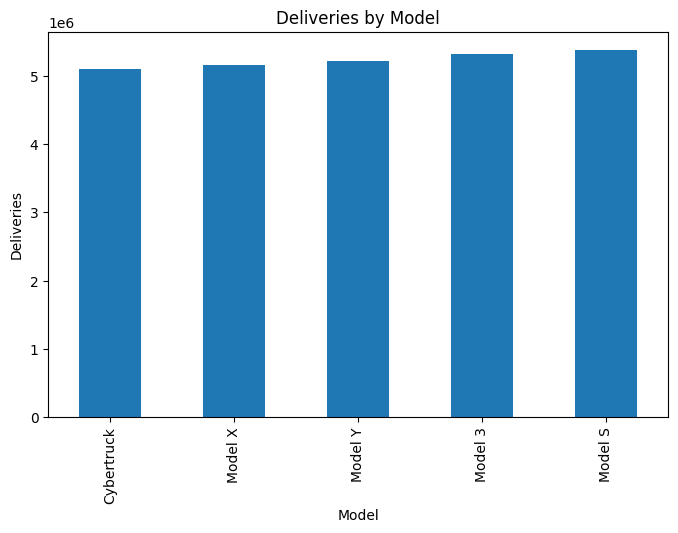

In [9]:
model_sales = df.groupby('Model')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8,5))
model_sales.sort_values().plot(kind='bar')
plt.title("Deliveries by Model")
plt.ylabel("Deliveries")
plt.show()

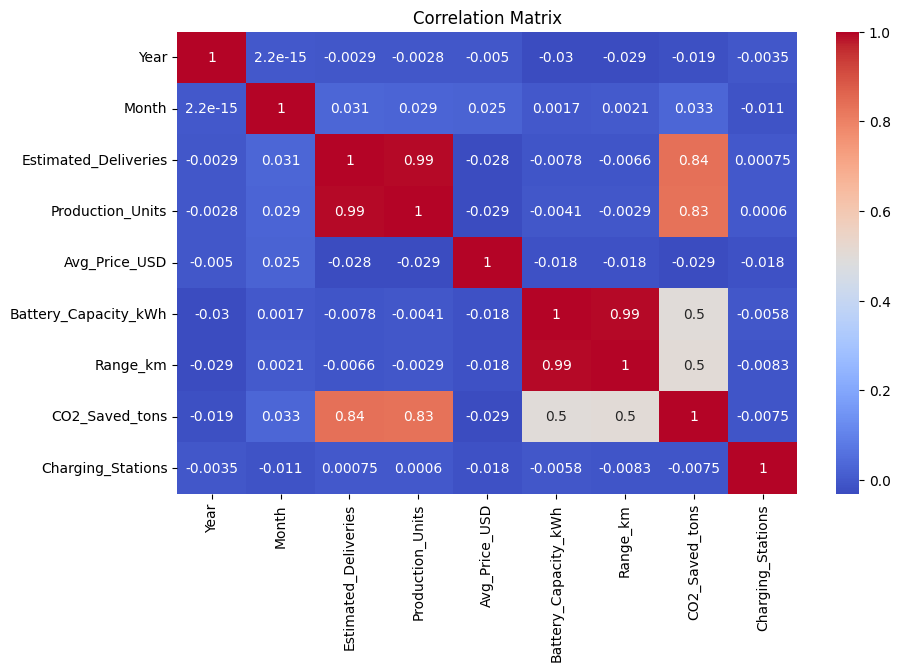

In [10]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

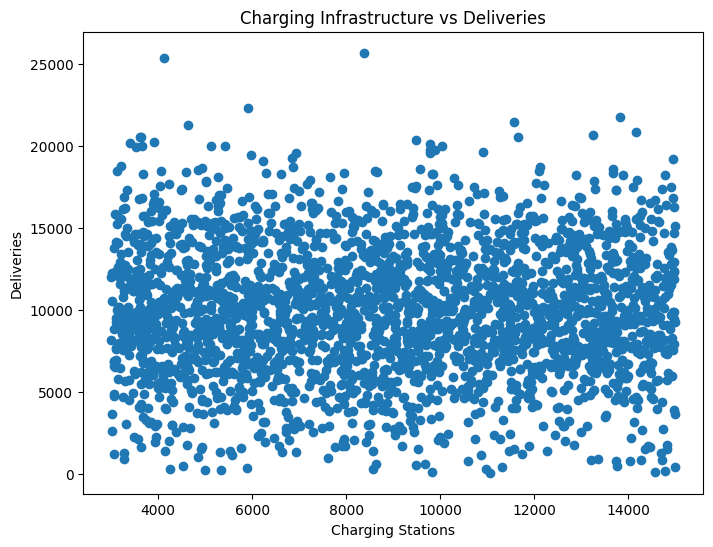

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Charging_Stations'],
    df['Estimated_Deliveries']
)

plt.xlabel("Charging Stations")
plt.ylabel("Deliveries")
plt.title("Charging Infrastructure vs Deliveries")
plt.show()

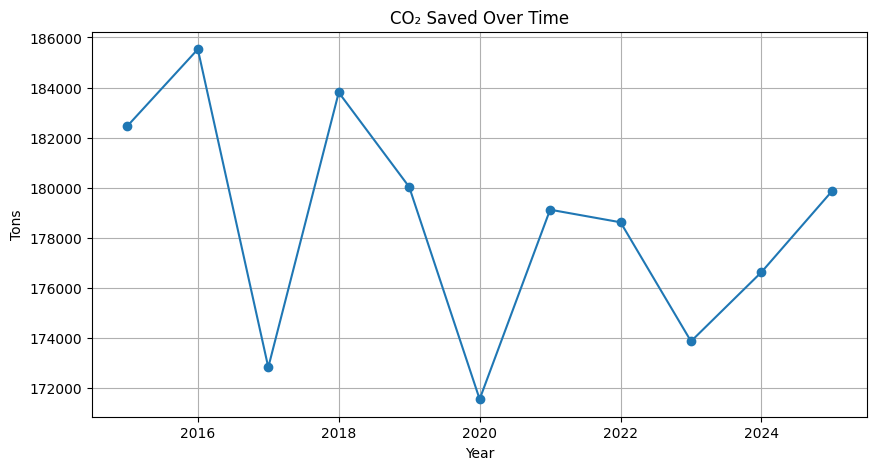

In [12]:
co2 = df.groupby('Year')['CO2_Saved_tons'].sum()

plt.figure(figsize=(10,5))
co2.plot(marker='o')
plt.title("CO₂ Saved Over Time")
plt.ylabel("Tons")
plt.grid(True)
plt.show()

# Key Findings

1. Tesla's estimated deliveries show a strong upward trend from 2015 to 2025, indicating growing adoption of electric vehicles globally.

2. Production units closely follow delivery volumes, suggesting efficient production planning and demand forecasting.

3. Certain regions contribute significantly more deliveries than others, highlighting Tesla's strongest markets.

4. Vehicle models exhibit different delivery volumes, helping identify the most popular Tesla products.

5. Charging infrastructure appears positively associated with vehicle deliveries, indicating the importance of charging accessibility in EV adoption.

6. CO₂ savings have increased over time, demonstrating the environmental benefits of expanding electric vehicle usage.

7. Battery capacity and driving range show a strong relationship, emphasizing the importance of battery technology in EV performance.

# Business Recommendations

- Continue expanding charging infrastructure in high-growth regions to support increasing EV adoption.

- Focus production resources on high-demand vehicle models to maximize market impact.

- Invest in battery technology improvements to increase vehicle range and customer satisfaction.

- Expand presence in underperforming regions with targeted marketing and infrastructure development.

- Utilize demand forecasting to maintain a balance between production and deliveries.

# Conclusion

This analysis examined Tesla's deliveries, production, pricing, battery specifications, charging infrastructure, and environmental impact from 2015 to 2025.

The results indicate sustained growth in deliveries and production, supported by expanding charging networks and advancements in battery technology. Increasing CO₂ savings further highlight the positive environmental impact of electric vehicle adoption.

Overall, Tesla demonstrates strong market growth and operational efficiency, reinforcing its position as a leading electric vehicle manufacturer.

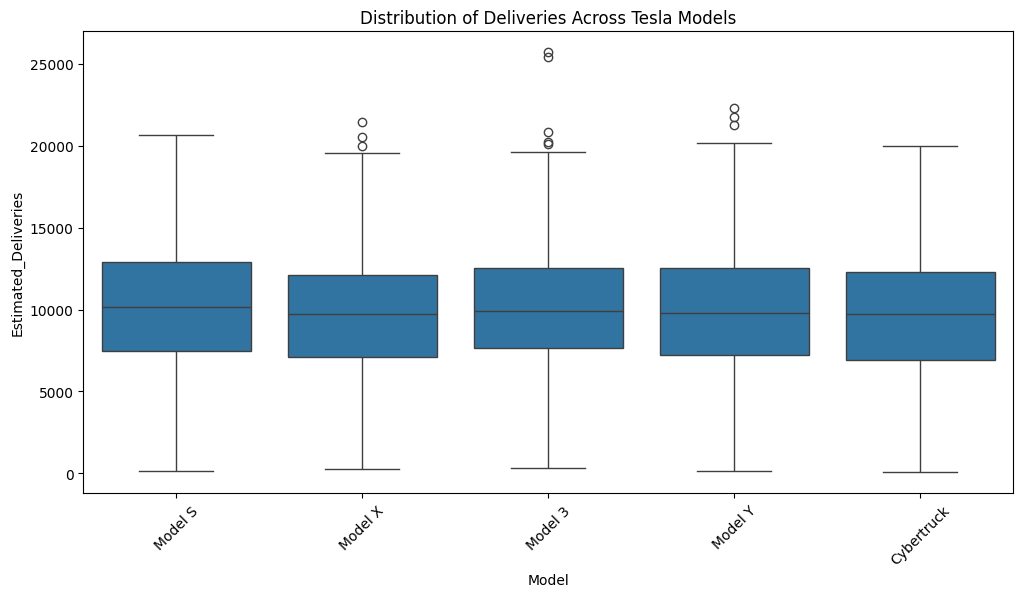

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Model',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Distribution of Deliveries Across Tesla Models")
plt.xticks(rotation=45)
plt.show()